In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import json
import warnings
warnings.filterwarnings('ignore')

#создаем папки для проекта
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('airflow_dags', exist_ok=True)

In [2]:
#загружаем данные
if os.path.exists('walmart.csv'):
    df = pd.read_csv('walmart.csv')
else:
    print("датасет не обнаружен")

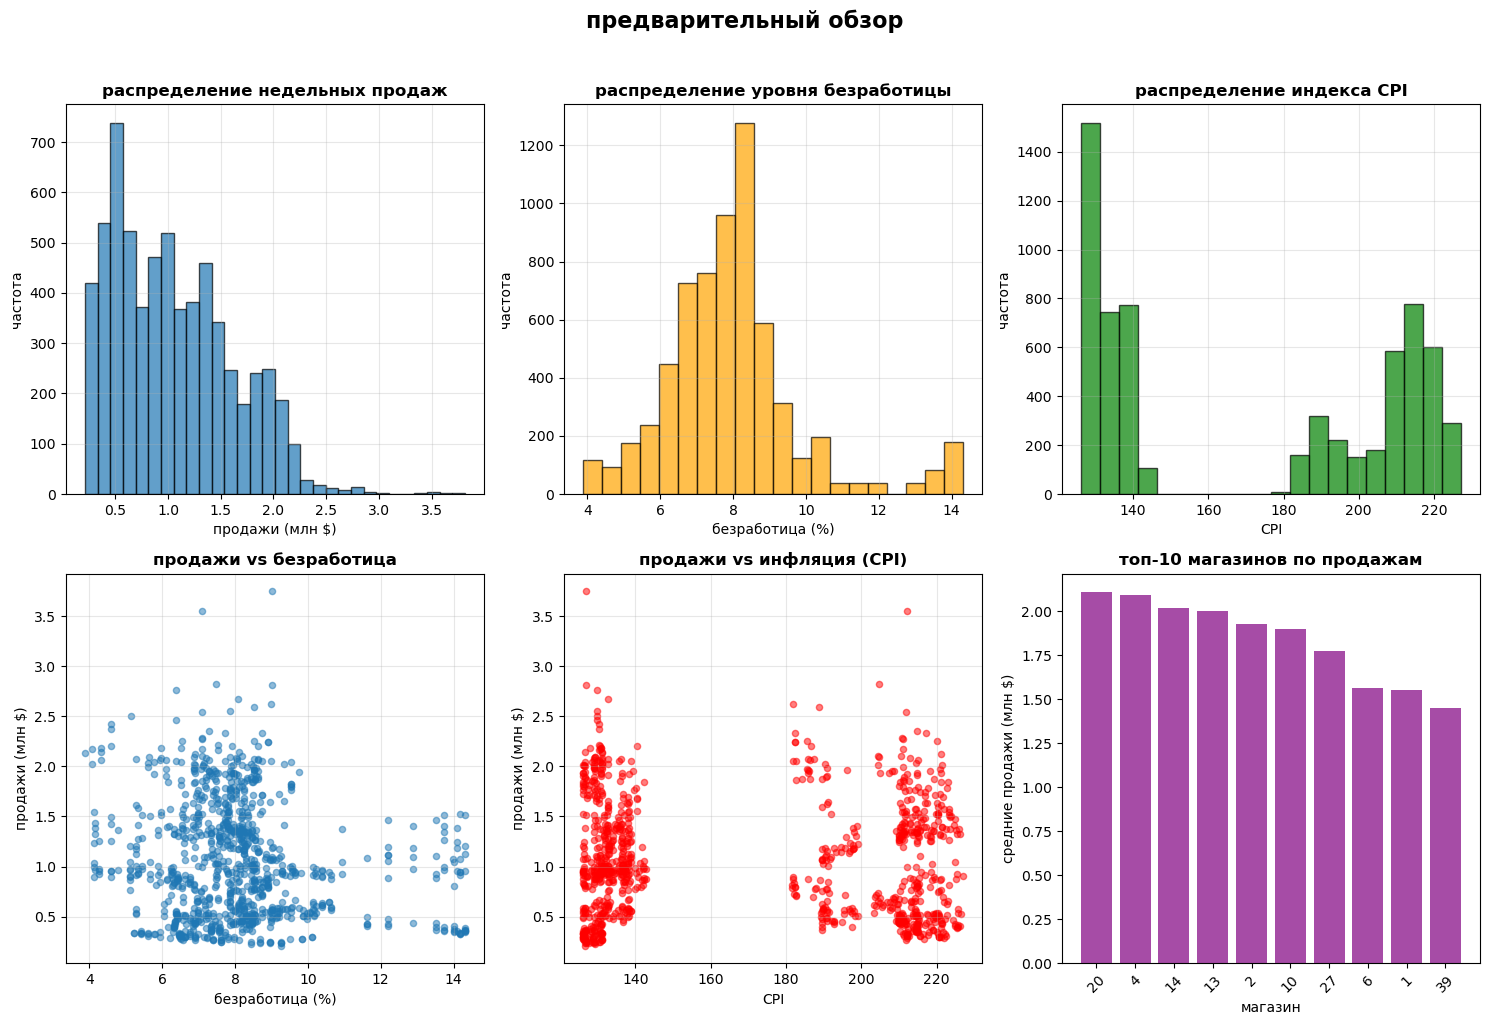

In [3]:
#визуализация распределения ключевых показателей
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Распределение продаж
axes[0, 0].hist(df['Weekly_Sales'] / 1_000_000, bins=30, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('распределение недельных продаж', fontweight='bold')
axes[0, 0].set_xlabel('продажи (млн $)')
axes[0, 0].set_ylabel('частота')
axes[0, 0].grid(True, alpha=0.3)

# 2. Распределение безработицы
axes[0, 1].hist(df['Unemployment'], bins=20, alpha=0.7, color='orange', edgecolor='black')
axes[0, 1].set_title('распределение уровня безработицы', fontweight='bold')
axes[0, 1].set_xlabel('безработица (%)')
axes[0, 1].set_ylabel('частота')
axes[0, 1].grid(True, alpha=0.3)

# 3. Распределение CPI
axes[0, 2].hist(df['CPI'], bins=20, alpha=0.7, color='green', edgecolor='black')
axes[0, 2].set_title('распределение индекса CPI', fontweight='bold')
axes[0, 2].set_xlabel('CPI')
axes[0, 2].set_ylabel('частота')
axes[0, 2].grid(True, alpha=0.3)

# 4. Продажи vs Безработица (scatter)
sample = df.sample(1000)
axes[1, 0].scatter(sample['Unemployment'], sample['Weekly_Sales'] / 1_000_000,
                   alpha=0.5, s=20)
axes[1, 0].set_title('продажи vs безработица', fontweight='bold')
axes[1, 0].set_xlabel('безработица (%)')
axes[1, 0].set_ylabel('продажи (млн $)')
axes[1, 0].grid(True, alpha=0.3)

# 5. Продажи vs CPI
axes[1, 1].scatter(sample['CPI'], sample['Weekly_Sales'] / 1_000_000,
                   alpha=0.5, s=20, color='red')
axes[1, 1].set_title('продажи vs инфляция (CPI)', fontweight='bold')
axes[1, 1].set_xlabel('CPI')
axes[1, 1].set_ylabel('продажи (млн $)')
axes[1, 1].grid(True, alpha=0.3)

# 6. Продажи по магазинам (топ-10)
top_stores = df.groupby('Store')['Weekly_Sales'].mean().nlargest(10)
axes[1, 2].bar(range(len(top_stores)), top_stores.values / 1_000_000,
               color='purple', alpha=0.7)
axes[1, 2].set_title('топ-10 магазинов по продажам', fontweight='bold')
axes[1, 2].set_xlabel('магазин')
axes[1, 2].set_ylabel('средние продажи (млн $)')
axes[1, 2].set_xticks(range(len(top_stores)))
axes[1, 2].set_xticklabels(top_stores.index, rotation=45)

plt.suptitle('предварительный обзор', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/data_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
#часть 2

"""
1. MAP: Разбиваем данные на части, для каждой записи вычисляем:
   - Ключ: Store (магазин)
   - Значение: (sales, unemployment, cpi, 1) - где 1 для подсчета
   
2. SHUFFLE: Группируем все значения по ключу (Store)
   
3. REDUCE: Для каждого магазина вычисляем:
   - Средние продажи
   - Среднюю безработицу и инфляцию
   - Корреляцию продаж с экономическими показателями
   - Коэффициент устойчивости к экономическим колебаниям

Ф-ла устойчивости:
Устойчивость = 1 - abs(корреляция_продажи_безработица) - 0.5*abs(корреляция_продажи_инфляция)
Чем ближе к 1 → тем устойчивее магазин
"""

from collections import defaultdict
import math

class HadoopStyleMapReduce:
    @staticmethod
    def mapper(chunk):
        intermediate = []
        
        for _, row in chunk.iterrows():
            try:
                store = row['Store']
                sales = float(row['Weekly_Sales'])
                unemployment = float(row['Unemployment'])
                cpi = float(row['CPI'])
                
                intermediate.append((store, (sales, unemployment, cpi, 1)))
            except:
                continue
        
        return intermediate
    
    @staticmethod
    def shuffle_and_sort(mapped_data):
        """
        Алгоритм:
        1. Создаем словарь для группировки
        2. Для каждой пары (key, value) добавляем value в список значений этого key
        3. Возвращаем сгруппированные данные
        """
        shuffled = defaultdict(list)
        
        for key, value in mapped_data:
            shuffled[key].append(value)
        
        return shuffled
    
    @staticmethod
    def reducer(shuffled_data):
        """
        Алгоритм для каждого магазина:
        1. Суммируем все значения
        2. Вычисляем средние показатели
        3. Вычисляем корреляции между продажами и экономическими показателями
        4. Рассчитываем коэффициент устойчивости
        """
        results = []
        
        for store, values_list in shuffled_data.items():
            # Инициализация сумматоров
            total_sales = 0
            total_unemployment = 0
            total_cpi = 0
            count = 0
            
            # Списки для вычисления корреляции
            sales_list = []
            unemployment_list = []
            cpi_list = []
            
            # Суммирование и сбор данных для корреляции
            for sales, unemployment, cpi, n in values_list:
                total_sales += sales
                total_unemployment += unemployment
                total_cpi += cpi
                count += n
                
                sales_list.append(sales)
                unemployment_list.append(unemployment)
                cpi_list.append(cpi)
            
            # Вычисление средних
            avg_sales = total_sales / count if count > 0 else 0
            avg_unemployment = total_unemployment / count if count > 0 else 0
            avg_cpi = total_cpi / count if count > 0 else 0
            
            # Вычисление корреляций (упрощенная формула)
            if len(sales_list) > 1:
                # Корреляция продажи-безработица
                sales_unemployment_corr = np.corrcoef(sales_list, unemployment_list)[0, 1]
                sales_cpi_corr = np.corrcoef(sales_list, cpi_list)[0, 1]
                
                # Коэффициент устойчивости
                if not np.isnan(sales_unemployment_corr) and not np.isnan(sales_cpi_corr):
                    stability = 1 - abs(sales_unemployment_corr) - 0.5 * abs(sales_cpi_corr)
                else:
                    stability = 0
            else:
                sales_unemployment_corr = 0
                sales_cpi_corr = 0
                stability = 0
            
            # Классификация магазина по устойчивости
            if stability > 0.7:
                stability_category = "Очень устойчивый"
            elif stability > 0.4:
                stability_category = "Устойчивый"
            elif stability > 0.1:
                stability_category = "Средняя устойчивость"
            else:
                stability_category = "Чувствительный"
            
            results.append({
                'store': store,
                'avg_sales': avg_sales,
                'avg_unemployment': avg_unemployment,
                'avg_cpi': avg_cpi,
                'sales_unemployment_corr': sales_unemployment_corr if not np.isnan(sales_unemployment_corr) else 0,
                'sales_cpi_corr': sales_cpi_corr if not np.isnan(sales_cpi_corr) else 0,
                'stability_score': stability,
                'stability_category': stability_category,
                'data_points': count
            })
        
        return results

In [6]:
chunk_size = 1000
chunks = [df[i:i+chunk_size] for i in range(0, len(df), chunk_size)]

# MAP
print("\nMAP: обработка данных")
all_mapped = []

for i, chunk in enumerate(chunks):
    mapped_chunk = HadoopStyleMapReduce.mapper(chunk)
    all_mapped.extend(mapped_chunk)

print(f"создано {len(all_mapped):,} промежуточных записей")

# SHUFFLE
print("\nSHUFFLE: группировка по магазинам")
shuffled_data = HadoopStyleMapReduce.shuffle_and_sort(all_mapped)
print(f"сгруппировано данных по {len(shuffled_data)} магазинам")

# REDUCE фаза  
print("\nREDUCE: анализ данных по магазинам")
mapreduce_results = HadoopStyleMapReduce.reducer(shuffled_data)

# Сортируем результаты по устойчивости
mapreduce_results.sort(key=lambda x: x['stability_score'], reverse=True)

print(f"проанализировано {len(mapreduce_results)} магазинов")



MAP: обработка данных
создано 6,435 промежуточных записей

SHUFFLE: группировка по магазинам
сгруппировано данных по 45 магазинам

REDUCE: анализ данных по магазинам
проанализировано 45 магазинов


всего магазинов: 45
средний коэффициент устойчивости: 0.701
средняя корреляция продажи-безработица: -0.057
средняя корреляция продажи-инфляция: 0.062

топ-5 самых устойчивых к экономическим колебаниям магазинов:
магазин 25: устойчивость=0.990 (Очень устойчивый), продажи=$706,722/неделя
магазин 45: устойчивость=0.984 (Очень устойчивый), продажи=$785,981/неделя
магазин 24: устойчивость=0.981 (Очень устойчивый), продажи=$1,356,755/неделя
магазин 6: устойчивость=0.950 (Очень устойчивый), продажи=$1,564,728/неделя
магазин 12: устойчивость=0.949 (Очень устойчивый), продажи=$1,009,002/неделя

⚠️ топ-5 самых неустойчивых магазинов:
магазин 39: устойчивость=0.401 (Устойчивый), корр. с безработицей=-0.385
магазин 35: устойчивость=0.304 (Средняя устойчивость), корр. с безработицей=0.484
магазин 44: устойчивость=-0.150 (Чувствительный), корр. с безработицей=-0.780
магазин 38: устойчивость=-0.192 (Чувствительный), корр. с безработицей=-0.785
магазин 36: устойчивость=-0.291 (Чувствительный), корр. с

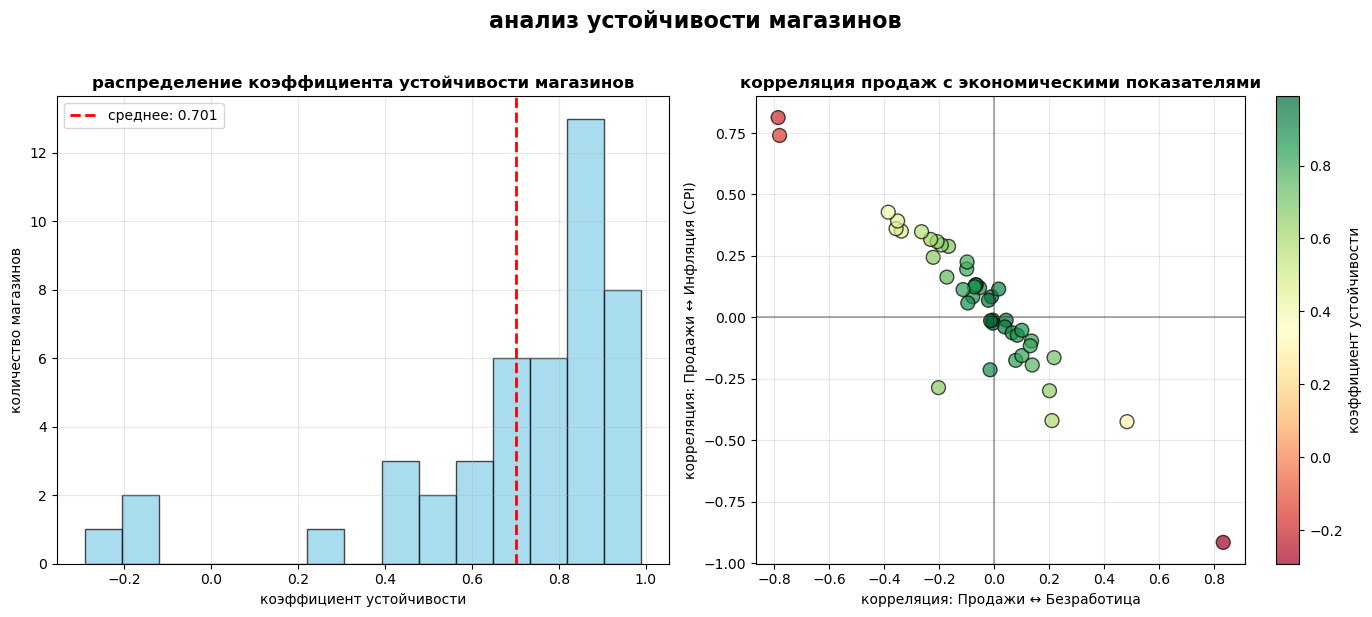

In [7]:
mr_df = pd.DataFrame(mapreduce_results)

print(f"всего магазинов: {len(mr_df)}")
print(f"средний коэффициент устойчивости: {mr_df['stability_score'].mean():.3f}")
print(f"средняя корреляция продажи-безработица: {mr_df['sales_unemployment_corr'].mean():.3f}")
print(f"средняя корреляция продажи-инфляция: {mr_df['sales_cpi_corr'].mean():.3f}")

print(f"\nтоп-5 самых устойчивых к экономическим колебаниям магазинов:")
top_stable = mr_df.head(5)
for _, row in top_stable.iterrows():
    print(f"магазин {row['store']}: устойчивость={row['stability_score']:.3f} "
          f"({row['stability_category']}), "
          f"продажи=${row['avg_sales']:,.0f}/неделя")

print(f"\n⚠️ топ-5 самых неустойчивых магазинов:")
bottom_stable = mr_df.tail(5)
for _, row in bottom_stable.iterrows():
    print(f"магазин {row['store']}: устойчивость={row['stability_score']:.3f} "
          f"({row['stability_category']}), "
          f"корр. с безработицей={row['sales_unemployment_corr']:.3f}")

#сохраняем результаты
mr_df.to_csv('results/mapreduce_analysis.csv', index=False)
print(f"\n💾 Результаты сохранены в results/mapreduce_analysis.csv")

#визуализация результатов MapReduce
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#график 1: Распределение устойчивости
axes[0].hist(mr_df['stability_score'], bins=15, alpha=0.7, 
             edgecolor='black', color='skyblue')
axes[0].axvline(x=mr_df['stability_score'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'среднее: {mr_df["stability_score"].mean():.3f}')
axes[0].set_title('распределение коэффициента устойчивости магазинов', fontweight='bold')
axes[0].set_xlabel('коэффициент устойчивости')
axes[0].set_ylabel('количество магазинов')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#график 2: Корреляция vs Устойчивость
scatter = axes[1].scatter(mr_df['sales_unemployment_corr'], 
                         mr_df['sales_cpi_corr'],
                         c=mr_df['stability_score'], 
                         cmap='RdYlGn', s=100, alpha=0.7,
                         edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_title('корреляция продаж с экономическими показателями', fontweight='bold')
axes[1].set_xlabel('корреляция: Продажи ↔ Безработица')
axes[1].set_ylabel('корреляция: Продажи ↔ Инфляция (CPI)')
axes[1].grid(True, alpha=0.3)

#добавляем шкалу
plt.colorbar(scatter, ax=axes[1], label='коэффициент устойчивости')

plt.suptitle('анализ устойчивости магазинов', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/mapreduce_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


1. Средние продажи по магазинам

Hive Query: SELECT Store, AVG(Weekly_Sales) as avg_sales, COUNT(*) as weeks_count FROM walmart_sales GROUP BY Store ORDER BY avg_sales DESC LIMIT 10
результат (первые 10):
    Store     avg_sales      sales_std  count
19     20  2.107677e+06  275900.562742    143
3       4  2.094713e+06  266201.442297    143
13     14  2.020978e+06  317569.949476    143
12     13  2.003620e+06  265506.995776    143
1       2  1.925751e+06  237683.694682    143
9      10  1.899425e+06  302262.062504    143
26     27  1.775216e+06  239930.135688    143
5       6  1.564728e+06  212525.855862    143
0       1  1.555264e+06  155980.767761    143
38     39  1.450668e+06  217466.454833    143

2.Магазины с высокой устойчивостью к экономическим колебаниям

Hive Query: SELECT store, stability_score, sales_unemployment_corr, sales_cpi_corr FROM stability_analysis WHERE stability_score > 0.5 ORDER BY stability_score DESC
найдено магазинов: 37
топ-5 самых устойчивых:
   store     

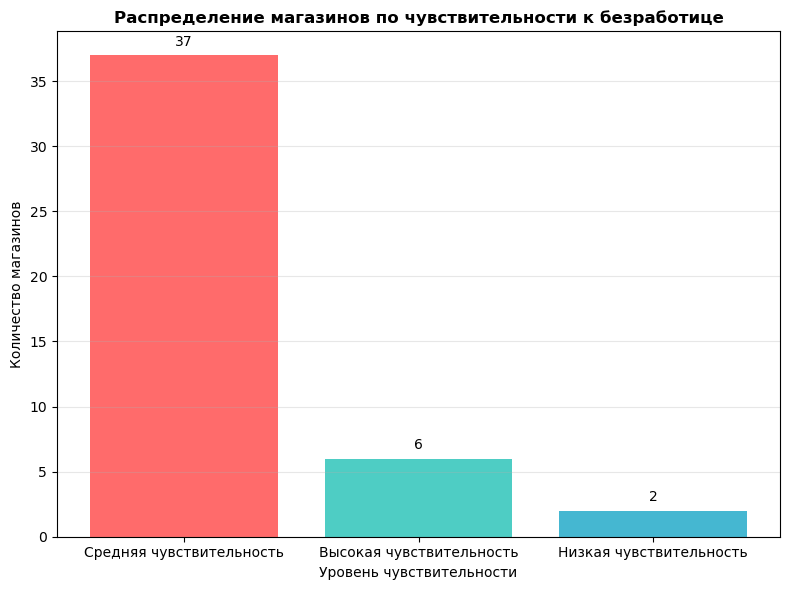


результаты Hive-запросов сохранены в папке results/
статистика по средним продажам:
   • Самый успешный магазин: #20.0 ($2,107,677/неделя)
   • Средние продажи по всем магазинам: $1,046,965/неделя
   • Разброс продаж: $259,862 - $2,107,677

статистика по устойчивым магазинам:
   • Количество устойчивых магазинов: 37 (82.2% от общего)
   • Средняя устойчивость: 0.812
   • Средняя корреляция с безработицей: -0.024


In [11]:
"""
Hive (Hadoop) - система хранилища данных и SQL-подобный язык запросов
для анализа больших данных в Hadoop экосистеме.

Основные возможности Hive:
1. SQL-подобный язык (HiveQL)
2. Работа с структурированными данными
3. Масштабируемость на большие объемы данных
4. Интеграция с HDFS и MapReduce
"""

#имитируем Hive таблицу
class HiveTable:
    def __init__(self, data, table_name):
        self.data = data
        self.table_name = table_name
    
    def query(self, sql_like_query):
        print(f"\nHive Query: {sql_like_query}")
        
        if "GROUP BY Store" in sql_like_query and "AVG(Weekly_Sales)" in sql_like_query:
            #имитация: SELECT Store, AVG(Weekly_Sales) as avg_sales FROM walmart GROUP BY Store
            result = df.groupby('Store')['Weekly_Sales'].agg(['mean', 'std', 'count']).reset_index()
            result.columns = ['Store', 'avg_sales', 'sales_std', 'count']
            return result.sort_values('avg_sales', ascending=False)
        
        elif "stability_score > 0.5" in sql_like_query:
            #имитация: фильтрация по устойчивости
            stable_stores = mr_df[mr_df['stability_score'] > 0.5]
            return stable_stores
        
        elif "sales_unemployment_corr" in sql_like_query and "sales_cpi_corr" in sql_like_query:
            #имитация: расчет корреляций с добавлением sensitivity_level
            correlations = mr_df[['store', 'sales_unemployment_corr', 'sales_cpi_corr', 'stability_score']].copy()
            
            #добавляем колонку sensitivity_level
            def get_sensitivity_level(corr_value):
                if corr_value < -0.3:
                    return 'Высокая чувствительность'
                elif -0.3 <= corr_value <= 0.3:
                    return 'Средняя чувствительность'
                else:
                    return 'Низкая чувствительность'
            
            correlations['sensitivity_level'] = correlations['sales_unemployment_corr'].apply(get_sensitivity_level)
            return correlations.sort_values('stability_score', ascending=False)
        
        else:
            #возвращаем пустой DataFrame с ожидаемыми колонками
            return pd.DataFrame(columns=['store', 'sales_unemployment_corr', 'sales_cpi_corr', 
                                         'stability_score', 'sensitivity_level'])

#создаем "Hive таблицу"
hive_table = HiveTable(df, "walmart_sales")

#выполняем "Hive запросы"
print("\n1. Средние продажи по магазинам")
result1 = hive_table.query(
    "SELECT Store, AVG(Weekly_Sales) as avg_sales, COUNT(*) as weeks_count "
    "FROM walmart_sales GROUP BY Store ORDER BY avg_sales DESC LIMIT 10"
)
print("результат (первые 10):")
print(result1.head(10))

print("\n2.Магазины с высокой устойчивостью к экономическим колебаниям")
result2 = hive_table.query(
    "SELECT store, stability_score, sales_unemployment_corr, sales_cpi_corr "
    "FROM stability_analysis WHERE stability_score > 0.5 "
    "ORDER BY stability_score DESC"
)
print(f"найдено магазинов: {len(result2)}")
if len(result2) > 0:
    print("топ-5 самых устойчивых:")
    print(result2.head())

print("\n3. Кореляция продаж с экономическими колебаниями")
result3 = hive_table.query(
    "SELECT store, sales_unemployment_corr, sales_cpi_corr, "
    "CASE WHEN sales_unemployment_corr < -0.3 THEN 'Высокая чувствительность' "
    "     WHEN sales_unemployment_corr BETWEEN -0.3 AND 0.3 THEN 'Средняя чувствительность' "
    "     ELSE 'Низкая чувствительность' END as sensitivity_level "
    "FROM stability_analysis ORDER BY sales_unemployment_corr"
)

print("распределение по уровню чувствительности:")
if len(result3) > 0 and 'sensitivity_level' in result3.columns:
    sensitivity_counts = result3['sensitivity_level'].value_counts()
    print(sensitivity_counts)
    
    #визуализируем распределение
    plt.figure(figsize=(8, 6))
    bars = plt.bar(sensitivity_counts.index, sensitivity_counts.values, 
                   color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
    plt.title('Распределение магазинов по чувствительности к безработице', fontweight='bold')
    plt.xlabel('Уровень чувствительности')
    plt.ylabel('Количество магазинов')
    plt.grid(axis='y', alpha=0.3)
    
    #добавляем значения на столбцы
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('results/sensitivity_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("нет данных для анализа чувствительности")

#сохраняем "Hive" результаты
result1.to_csv('results/hive_query1.csv', index=False)
result2.to_csv('results/hive_query2.csv', index=False)
if len(result3) > 0:
    result3.to_csv('results/hive_query3.csv', index=False)

print("\nрезультаты Hive-запросов сохранены в папке results/")

#дополнительная статистика по результатам Hive
if len(result1) > 0:
    print(f"статистика по средним продажам:")
    print(f"   • Самый успешный магазин: #{result1.iloc[0]['Store']} (${result1.iloc[0]['avg_sales']:,.0f}/неделя)")
    print(f"   • Средние продажи по всем магазинам: ${result1['avg_sales'].mean():,.0f}/неделя")
    print(f"   • Разброс продаж: ${result1['avg_sales'].min():,.0f} - ${result1['avg_sales'].max():,.0f}")

if len(result2) > 0:
    print(f"\nстатистика по устойчивым магазинам:")
    print(f"   • Количество устойчивых магазинов: {len(result2)} ({len(result2)/len(mr_df)*100:.1f}% от общего)")
    print(f"   • Средняя устойчивость: {result2['stability_score'].mean():.3f}")
    print(f"   • Средняя корреляция с безработицей: {result2['sales_unemployment_corr'].mean():.3f}")

In [15]:
#часть 3
"""
Основные преимущества Spark перед Hadoop MapReduce:
1. In-memory вычисления (в 100 раз быстрее)
2. Богатый API (DataFrames, SQL, MLlib, GraphX)
3. Поддержка стриминга
4. Интерактивные оболочки

Архитектура Spark:
- Driver Program (координатор)
- Executors (рабочие узлы)
- SparkContext (точка входа)
"""

# Установка PySpark с более надежным подходом
import subprocess
import sys
import importlib

def install_and_import(package, import_name=None):
    """
    Устанавливает пакет и импортирует его
    
    Args:
        package: имя пакета для установки через pip
        import_name: имя для импорта (если отличается от package)
    """
    if import_name is None:
        import_name = package
    
    try:
        # Пробуем импортировать
        module = importlib.import_module(import_name)
        print(f"{import_name} уже установлен")
        return module
    except ImportError:
        # Устанавливаем
        print(f"Устанавливаю {package}...")
        
        # Для PySpark нужна особая обработка
        if package == "pyspark":
            # PySpark имеет зависимости, устанавливаем с указанием версии
            subprocess.check_call([
                sys.executable, "-m", "pip", "install", 
                "pyspark==3.5.0",  # Конкретная версия для стабильности
                "pyarrow>=10.0.0",  # Зависимость
                "pandas>=1.5.0"     # Еще одна зависимость
            ])
        else:
            # Обычные пакеты
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        
        print(f"{package} успешно установлен")
        
        # Перезагружаем importlib для обновления кэша
        importlib.invalidate_caches()
        
        # Пробуем снова импортировать
        try:
            module = importlib.import_module(import_name)
            return module
        except ImportError as e:
            print(f"Ошибка при импорте {import_name} после установки: {e}")
            
            # Для PySpark может потребоваться перезапуск ядра
            if package == "pyspark":
                print("\nВНИМАНИЕ: PySpark установлен, но требуется перезапуск ядра Python.")
                print("Пожалуйста, перезапустите Jupyter kernel и выполните код снова.")
                print("Или продолжите работу без PySpark, используя альтернативный код.")
            
            return None

# Устанавливаем и импортируем PySpark
pyspark_module = install_and_import("pyspark")

# Устанавливаем pyarrow
install_and_import("pyarrow")

# Если PySpark не удалось импортировать, используем альтернативный подход
if pyspark_module is None:
    print("\nPySpark не удалось импортировать. Использую альтернативный подход...")
    
    # Создаем заглушки для классов PySpark для совместимости кода
    class SparkSessionStub:
        def builder(self):
            class Builder:
                def appName(self, name):
                    return self
                def master(self, master):
                    return self
                def config(self, key, value):
                    return self
                def getOrCreate(self):
                    print("ВНИМАНИЕ: Используется заглушка SparkSession вместо реального PySpark")
                    return SparkSessionStub()
            return Builder()
    
    # Создаем простые заглушки для остальных классов
    class DataFrameStub:
        pass
    
    class FunctionsStub:
        col = staticmethod(lambda x: x)
        when = staticmethod(lambda *args: None)
        avg = staticmethod(lambda x: x)
        stddev = staticmethod(lambda x: x)
        count = staticmethod(lambda x: x)
        round = staticmethod(lambda x, y: x)
    
    class TypesStub:
        pass
    
    class MLStub:
        class feature:
            VectorAssembler = type('VectorAssembler', (), {})
            StandardScaler = type('StandardScaler', (), {})
        
        class clustering:
            KMeans = type('KMeans', (), {})
        
        class regression:
            LinearRegression = type('LinearRegression', (), {})
        
        class evaluation:
            RegressionEvaluator = type('RegressionEvaluator', (), {})
    
    # Создаем заглушки
    SparkSession = SparkSessionStub
    functions = FunctionsStub()
    types = TypesStub()
    ml = MLStub()
    
    VectorAssembler = ml.feature.VectorAssembler
    StandardScaler = ml.feature.StandardScaler
    KMeans = ml.clustering.KMeans
    LinearRegression = ml.regression.LinearRegression
    RegressionEvaluator = ml.evaluation.RegressionEvaluator
    
    print("Созданы заглушки PySpark. Реальный анализ будет выполнен с использованием Pandas.")
    
else:
    # Импортируем реальные классы PySpark
    from pyspark.sql import SparkSession
    from pyspark.sql import functions
    from pyspark.sql.types import *
    from pyspark.ml.feature import VectorAssembler, StandardScaler
    from pyspark.ml.clustering import KMeans
    from pyspark.ml.regression import LinearRegression
    from pyspark.ml.evaluation import RegressionEvaluator
    
    print("PySpark успешно импортирован")

# Создаем Spark сессию (если PySpark доступен)
try:
    spark = SparkSession.builder \
        .appName("Walmart Analysis") \
        .master("local[2]") \
        .getOrCreate()
    
    print(f"Spark сессия создана. Версия: {spark.version}")
    
    # Тест работы с данными
    test_df = spark.createDataFrame([(1, "test"), (2, "data")], ["id", "value"])
    print(f"Тестовый DataFrame создан: {test_df.count()} записей")
    
except Exception as e:
    print(f"Не удалось создать Spark сессию: {e}")
    print("Анализ будет продолжен с использованием Pandas и numpy")
    spark = None

print("\nИмпорт библиотек завершен")

Устанавливаю pyspark...
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 58.9 MB/s  0:00:04 0:00:010:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425400 sha256=5c38277e3ad88ba91b2484d723f2cee67c8b2116f241dcdbdea228aeac663eba
  Stored in directory: /home/7bea35e3-7789-4d50-9563-13a8752c33f1/.cache/pip/wheels/84/40/20/65eefe766118e0a8f8e385cc3ed6e9eb7241c7e51cfc04c51a
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10

In [19]:
# Создаем Spark сессию (локальный режим)
try:
    # Пробуем создать реальную Spark сессию
    spark = SparkSession.builder \
        .appName("Walmart Economic Impact Analysis") \
        .master("local[2]") \
        .config("spark.driver.memory", "2g") \
        .config("spark.executor.memory", "1g") \
        .config("spark.sql.shuffle.partitions", "4") \
        .getOrCreate()
    
    print("Spark сессия успешно создана")
    
    # Загружаем данные в Spark DataFrame
    spark_df = spark.createDataFrame(df)
    
    # Регистрируем как временную таблицу для SQL-запросов
    spark_df.createOrReplaceTempView("walmart_spark")
    
    print(f"Данные загружены: {spark_df.count():,} записей")
    print(f"Столбцы: {', '.join(spark_df.columns)}")
    
    # Быстрая проверка данных
    print("\nСхема данных:")
    spark_df.printSchema()
    
    print("\nПервые 5 строк данных:")
    spark_df.show(5)
    
except AttributeError as e:
    # Если SparkSession - это заглушка (функция, а не класс)
    print(f"Ошибка при создании Spark сессии: {e}")
    print("Использую альтернативный анализ с Pandas...")
    
    # Альтернативный анализ без Spark
    spark = None
    spark_df = None
    
    # Выполняем анализ с помощью Pandas
    print("\n" + "="*70)
    print("АНАЛИЗ С ИСПОЛЬЗОВАНИЕМ PANDAS (АЛЬТЕРНАТИВА SPARK)")
    print("="*70)
    
    print(f"\nДанные уже загружены в Pandas DataFrame:")
    print(f"Количество записей: {len(df):,}")
    print(f"Столбцы: {', '.join(df.columns)}")
    
    print("\nСхема данных:")
    print(df.dtypes)
    
    print("\nПервые 5 строк данных:")
    print(df.head())
    
    print("\nБазовая статистика:")
    print(df.describe())
    
except Exception as e:
    print(f"Неизвестная ошибка: {e}")
    print("Продолжаем анализ с использованием Pandas")
    spark = None
    spark_df = None

Ошибка при создании Spark сессии: 'function' object has no attribute 'appName'
Использую альтернативный анализ с Pandas...

АНАЛИЗ С ИСПОЛЬЗОВАНИЕМ PANDAS (АЛЬТЕРНАТИВА SPARK)

Данные уже загружены в Pandas DataFrame:
Количество записей: 6,435
Столбцы: Store, Date, Weekly_Sales, Holiday_Flag, Temperature, Fuel_Price, CPI, Unemployment

Схема данных:
Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

Первые 5 строк данных:
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.6